In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

**Zadanie 1**

Przygotuj i wyświetl wykres liniowy funkcji f(x) = 1/x dla x ϵ [1, 20]. Dodaj etykietę do linii wykresu i wyświetl legendę. Dodaj odpowiednie etykiety do osi wykresu (‘x’, ’f(x)’) oraz ustaw zakres dla obu osi na (0, 1) oraz (1, długość wektora x).

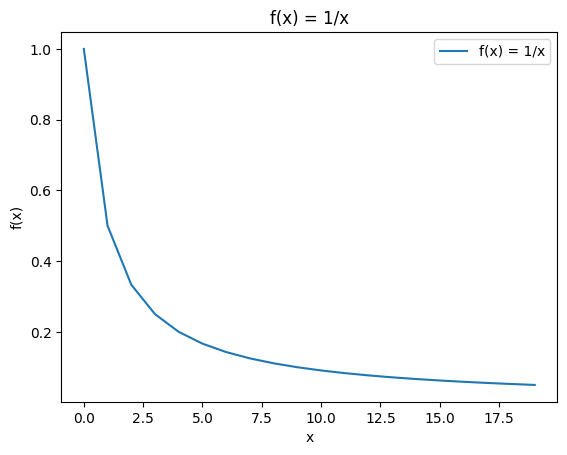

In [2]:
x_ = list(map(lambda x: 1/x, np.arange(1,21)))
plt.plot(x_, label='f(x) = 1/x')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = 1/x')
plt.legend()
plt.show()

**Zadanie 2**

Korzystając ze zbioru danych [zamowienia.csv](./data/zamowienia.csv) przygotuj i wyświetl:
- dane w postaci wykresu liniowego 
- z sumą zamówień dla każdego sprzedawcy z Polski 
- w roku 2004 grupując po miesiącach (wzoruj się przykładzie z pkt. 3 tego labu). 
- Każdy wykres to linia dla danego sprzedawcy, a oś x reprezentuje kolejne miesiące roku 2004. 
- Pamiętaj o tym, że można iterować przez zgrupowaną ramkę danych pandas.



In [3]:
df_zam = pd.read_csv(r"C:\anal_danych\Labs\swps-metody-analizy-danych\data\zamowienia.csv", sep=';')

df_pol = df_zam[df_zam['Kraj'] == 'Polska']

df_2004 = df_pol[df_pol['Data zamowienia'].str[:4] == '2004'].copy()

df_2004['Month'] = pd.to_datetime(df_2004['Data zamowienia']).dt.month

df_res = df_2004.groupby([df_2004['Month'], df_2004['Sprzedawca']]).agg({'idZamowienia': 'count'}).reset_index()
df_res


,Month,Sprzedawca,idZamowienia
0,1,Dudek,2
1,1,King,2
2,1,Kowalski,1
3,1,Sowiński,1
4,2,King,1
5,2,Sowiński,4
6,3,King,1
7,3,Kowalski,3
8,3,Sowiński,1
9,4,Dudek,2


In [4]:
df_res['Sprzedawca'].unique()

array(['Dudek', 'King', 'Kowalski', 'Sowiński'], dtype=object)

In [5]:
data = df_res[df_res['Sprzedawca'] == 'King']
data

,Month,Sprzedawca,idZamowienia
1,1,King,2
4,2,King,1
6,3,King,1
10,4,King,7
13,5,King,5
17,6,King,2
21,7,King,4
24,8,King,3
28,9,King,5
32,10,King,2


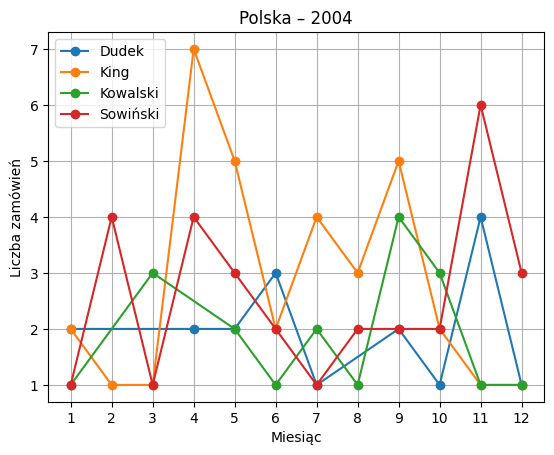

In [6]:
for sprzedawca in df_res['Sprzedawca'].unique():
    data = df_res[df_res['Sprzedawca'] == sprzedawca]
    
    plt.plot(data['Month'], data['idZamowienia'], marker='o', label=sprzedawca)

plt.xlabel('Miesiąc')
plt.ylabel('Liczba zamówień')
plt.title('Polska – 2004')
plt.xticks(range(1,13))
plt.legend()
plt.grid()

plt.show()

In [7]:
for i in df_res.index:
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42


In [8]:
df_zam

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90
...,...,...,...,...,...
794,Polska,King,2005-04-30,11048,525.00
795,Niemcy,Leverling,2005-05-01,11052,1332.00
796,Niemcy,Fuller,2005-04-29,11053,3055.00
797,Niemcy,Callahan,2005-05-01,11056,3740.00


In [9]:
df_pol = df_zam[df_zam['Kraj'] == 'Polska']
df_pol

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
6,Polska,Kowalski,2003-07-23,10254,556.62
7,Polska,Dudek,2003-07-15,10255,2490.50
15,Polska,Dudek,2003-07-31,10263,1873.80
...,...,...,...,...,...
782,Polska,King,2005-04-23,11033,3232.80
786,Polska,King,2005-04-27,11037,60.00
790,Polska,Kowalski,2005-04-29,11043,210.00
793,Polska,King,2005-05-01,11047,817.87


In [10]:
df_2004

,Kraj,Sprzedawca,Data zamowienia,idZamowienia,Utarg,Month
147,Polska,Sowiński,2004-01-03,10395,2122.92,1
149,Polska,Kowalski,2004-01-02,10397,716.72,1
158,Polska,King,2004-01-13,10406,1830.78,1
163,Polska,Dudek,2004-01-21,10411,966.80,1
175,Polska,Sowiński,2004-02-24,10423,1020.00,2
...,...,...,...,...,...,...
516,Polska,Sowiński,2004-12-08,10764,2286.00,12
523,Polska,Dudek,2004-01-02,10771,344.00,1
527,Polska,King,2004-12-26,10775,228.00,12
534,Polska,Dudek,2004-12-22,10782,12.50,12


**Zadanie 3**

Korzystając z biblioteki pandas wczytaj zbiór danych z [narodzinami dzieci](./data/imiona.xlsx) przygotuj poniższe wykresy:
* 3.1 - wykres słupkowy przedstawiający ilość narodzonych dziewczynek i chłopców w całym okresie.
* 3.2 - wykres liniowy, gdzie będą dwie linie, jedna dla ilości urodzonych kobiet, druga dla mężczyzn dla każdego roku z osobna. Czyli y to ilość narodzonych kobiet lub mężczyzn (dwie linie), x to rok.
* 3.3 - wykres słupkowy przedstawiający sumę urodzonych dzieci w każdym roku.

Dodaj do wykresów stosowne etykiety. Poustawiaj różne kolory dla wykresów.



In [11]:
kids_born = pd.read_excel(r"C:\anal_danych\Labs\swps-metody-analizy-danych\data\imiona.xlsx")
kids_born.head(3)

,Rok,Imie,Liczba,Plec
0,2000,JAKUB,14497,M
1,2000,MATEUSZ,11454,M
2,2000,KACPER,8898,M


In [12]:
woman = kids_born[kids_born['Plec'] == 'K']
w_born = woman[['Liczba']].sum()

man = kids_born[kids_born['Plec'] == 'M']
m_born = man[['Liczba']].sum()

etykiety = ['Kobieta', 'Mężczyzna']
values = [w_born.values[0], m_born.values[0]]
values

[np.int64(3521321), np.int64(3714961)]

Text(0.5, 1.0, 'Liczba narodzonych dziewczynek i chłopców')

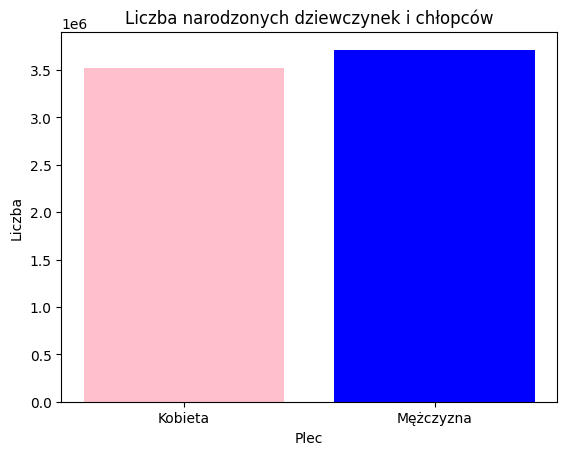

In [13]:
#* 3.1 - wykres słupkowy przedstawiający ilość narodzonych dziewczynek i chłopców w całym okresie.

plt.bar(etykiety, values, color=['pink', 'blue'])
plt.xlabel('Plec')
plt.ylabel('Liczba')
plt.title('Liczba narodzonych dziewczynek i chłopców')

In [14]:
kids_born.head(3)

,Rok,Imie,Liczba,Plec
0,2000,JAKUB,14497,M
1,2000,MATEUSZ,11454,M
2,2000,KACPER,8898,M


In [15]:
# 3.2 - wykres liniowy, gdzie będą dwie linie, jedna dla ilości urodzonych kobiet, druga dla mężczyzn dla każdego roku z osobna. Czyli y to ilość narodzonych kobiet lub mężczyzn (dwie linie), x to rok.
woman_kids = kids_born[kids_born['Plec'] == 'K']
woman_kids_born_per_year = woman_kids.groupby('Rok').agg({'Liczba': 'sum'}).reset_index()
man_kids = kids_born[kids_born['Plec'] == 'M']
man_kids_born_per_year = man_kids.groupby('Rok').agg({'Liczba': 'sum'}).reset_index()
man_kids_born_per_year

,Rok,Liczba
0,2000,197263
1,2001,191947
2,2002,185415
3,2003,183215
4,2004,186903
5,2005,192820
6,2006,200796
7,2007,211946
8,2008,227408
9,2009,230881


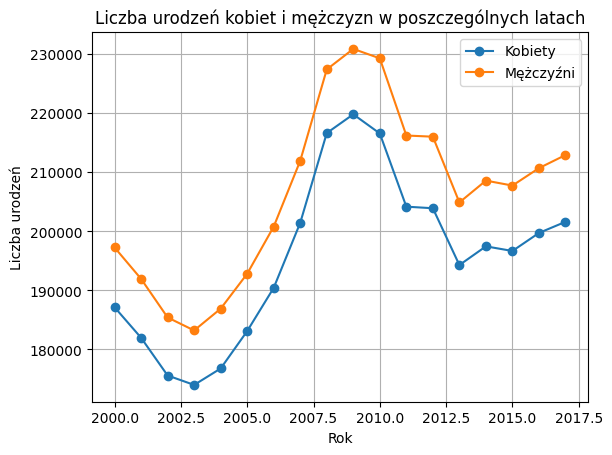

In [16]:
year = kids_born['Rok'].unique()

plt.xlabel('Rok')
plt.ylabel('Liczba urodzeń')
plt.title('Liczba urodzeń kobiet i mężczyzn w poszczególnych latach')
plt.plot(year, woman_kids_born_per_year['Liczba'], marker='o', label='Kobiety')
plt.plot(year, man_kids_born_per_year['Liczba'], marker='o', label='Mężczyźni')
plt.legend()
plt.grid()

In [17]:
a =kids_born['Rok'].unique()
a

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017])

      Liczba        
Plec       K       M
Rok                 
2000  187142  197263
2001  181975  191947
2002  175590  185415
2003  173995  183215
2004  176779  186903
2005  183112  192820
2006  190437  200796
2007  201448  211946
2008  216632  227408
2009  219811  230881
2010  216566  229289
2011  204174  216221
2012  203908  216021
2013  194290  204890
2014  197456  208585
2015  196672  207746
2016  199724  210699
2017  201610  212916


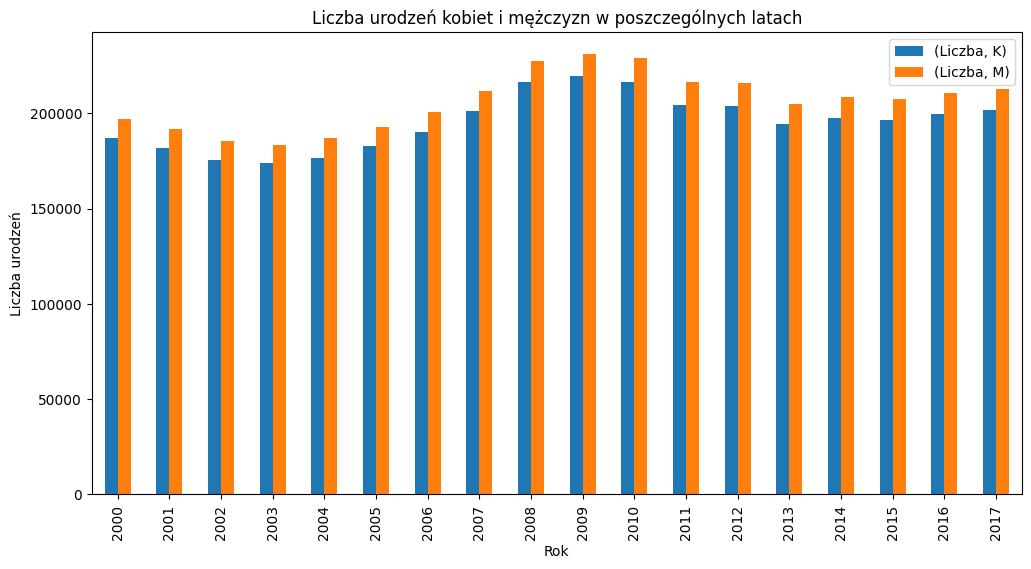

In [18]:
#* 3.3 - wykres słupkowy przedstawiający sumę urodzonych dzieci w każdym roku.
kids_born_per_year = kids_born.groupby(['Rok','Plec']).agg({'Liczba': 'sum'}).unstack()
print(kids_born_per_year)
kids_born_per_year.plot(kind='bar', figsize=(12,6))
plt.xlabel('Rok')
plt.ylabel('Liczba urodzeń')
plt.title('Liczba urodzeń kobiet i mężczyzn w poszczególnych latach')
plt.legend()

**Zadanie 4**

Korzystając ze zbioru danych Iris (https://archive.ics.uci.edu/ml/datasets/iris) wygeneruj wykres punktowy, gdzie wektor x to wartość `sepal length` a y to `sepal width`, dodaj paletę kolorów `c` na przykładzie listingu 7, a parametr `s` niech będzie wartością bezwzględną z różnicy wartości poszczególnych elementów wektorów x oraz y. Wykorzystaj bibliotekę pandas do przechowania datasetu.

**Zadanie 5**

Korzystając z pliku [zamowienia.csv](./data/zamowienia.csv), policz sumy zamówień dla każdego sprzedawcy i wyświetl wykres kołowy z procentowym udziałem każdego sprzedawcy w ogólnej sumie zamówień. Poszukaj w Internecie jak dodać cień do takiego wykresu i jak działa atrybut `explode` tego wykresu. Wyświetl wykres podstawowy, z cieniem oraz z jednym elementem z aktywnym atrybutem `explode`.

**Zadanie 6**

Korzystając z galerii matplotlib i [przykładu](https://matplotlib.org/stable/gallery/misc/packed_bubbles.html#sphx-glr-gallery-misc-packed-bubbles-py) postaraj się umieścić analogicznie 10 najbardziej ludnych krajów na świecie w roku 2017 korzystając z danych w pliku [ludność](./data/ludnosc.xlsx).